# 02 Supervised Machine Learning Models

This notebook applies the supervised learning algorithms required for Part II of the project. The primary task is score prediction, where the target `score` is treated as a numeric outcome and evaluated with regression metrics. A secondary task is high-score classification, where the derived target `high_score` indicates whether a rating is at least 7.

The model comparison is intentionally broad. Linear models provide interpretable baselines, regularised models test whether coefficient shrinkage improves generalisation, SVM and K-NN evaluate distance and margin-based learning, decision trees and ensembles capture non-linear interactions, and neural networks test whether a learned non-linear representation improves predictive performance. The notebook also records fit time because model quality must be evaluated together with computational cost.


In [1]:
import os
import sys
import time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath('..'))

RANDOM_STATE = 42
SAMPLE_SIZE = 50000
RATING_DTYPES = {
    'username': 'category',
    'anime_id': 'int32',
    'status': 'category',
    'score': 'float32',
    'is_rewatching': 'float32',
    'num_watched_episodes': 'float32',
}

%matplotlib inline
sns.set_theme(style='whitegrid')


In [2]:
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import plot_tree

from src.evaluate import (
    compute_classification_metrics,
    plot_classification_metrics,
    plot_fit_times,
    plot_regression_metrics,
)
from src.export_rf_tree import export_random_forest_tree
from src.models import get_models
from src.preprocessing import build_preprocess
from src.train import evaluate_model, train_and_log


## Data Preparation and Targets

The dataset is sampled to make experimentation computationally feasible while preserving a large enough subset for meaningful model comparison. The target for regression is `score`, and all remaining columns are considered candidate predictors after preprocessing. The train-test split creates an unseen test set so that RMSE, MAE, and R2 estimate generalisation rather than training memorisation.

The preprocessing pipeline handles the mixed structure of the MyAnimeList data. Numeric variables are imputed and scaled, while categorical variables are imputed and one-hot encoded. High-cardinality identifiers are excluded by the preprocessing function because they can dominate the feature space and encourage memorisation. This design is appropriate for general predictive modelling, while user and item identifiers are handled more naturally by the recommendation notebook.


### SVR Polynomial Kernel Stability

The polynomial SVR kernel is kept in the baseline comparison because the assignment requires analysis of multiple SVM kernels. However, it may exhibit numerical instability on this dataset, sometimes producing predictions far outside the natural 0-10 score range even with a larger iteration budget. This behaviour is interpreted rather than hidden: SVR_linear and SVR_rbf provide the stable SVM baselines, while SVR_poly demonstrates that kernel choice can strongly affect both predictive performance and numerical stability.


In [3]:
df = pd.read_csv('../datasets/ratings.csv', dtype=RATING_DTYPES)
df = df[df['score'] > 0]
df = df[df['num_watched_episodes'] <= 10000]
df = df[df['num_watched_episodes'] >= 0]
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

TARGET = 'score'
X_df = df.drop(columns=[TARGET]).copy()
y = df[TARGET].copy()

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocess = build_preprocess(df, TARGET)
X_train = preprocess.fit_transform(X_train_df)
X_test = preprocess.transform(X_test_df)

print('Regression target:', TARGET)
print('Feature columns:', X_df.columns.tolist())


Regression target: score
Feature columns: ['username', 'anime_id', 'status', 'is_rewatching', 'num_watched_episodes']


## Regression Models: Linear, Ridge, Lasso, SVM Kernels, K-NN, Trees, Ensembles, and Neural Networks

The regression comparison estimates the continuous `score` value. Linear Regression is an important baseline because it assumes an additive linear relationship between predictors and rating. It is fast and interpretable, but it may underfit if rating behaviour depends on complex interactions between status, progress, and categorical variables.

Ridge and Lasso Regression extend linear regression by adding regularisation. Ridge penalises large coefficients using an L2 penalty and is useful when many encoded features are correlated. Lasso uses an L1 penalty, which can shrink some coefficients exactly to zero and therefore behaves like embedded feature selection. These models are appropriate for sparse one-hot encoded data, although they may still miss non-linear patterns.

SVR models with linear, RBF, and polynomial kernels test different assumptions about the functional form of the relationship. A linear kernel resembles a margin-based linear model, the RBF kernel can capture local non-linear effects, and the polynomial kernel tests higher-order feature interactions. K-NN regression is non-parametric and predicts scores from nearby observations, but it can be sensitive to scaling, sparse features, and the selected number of neighbours. Decision Trees and Random Forests are suitable because they can model non-linear interactions and threshold effects; ensembles usually improve stability relative to a single tree. Neural networks, represented by single-layer and multi-layer MLP regressors, can approximate complex functions, but they require more training time and may not outperform simpler models if the engineered feature space is not rich enough.

The displayed RMSE, MAE, and R2 results should be interpreted together. RMSE penalises large errors more strongly than MAE, so a model with low RMSE is less prone to severe mistakes. MAE is easier to interpret on the 1 to 10 rating scale because it represents average absolute score error. R2 indicates the proportion of variance explained; low or negative R2 suggests that the model is not improving much over a simple mean prediction. Fit-time plots identify whether performance gains justify computational cost.


In [4]:
models = get_models('regression')
regression_results = []

mlflow.set_experiment('Projeto_Grupo_8')
while mlflow.active_run():
    mlflow.end_run()
with mlflow.start_run(nested=True, run_name='02_regression_models'):
    for name, model in models.items():
        print(f'Training {name}...')
        fitted, fit_time = train_and_log(name, clone(model), X_train, y_train)
        metrics = evaluate_model(name, fitted, X_test, y_test)
        regression_results.append({'model': name, 'fit_time': fit_time, **metrics})

df_regression = pd.DataFrame(regression_results).sort_values('rmse')
display(df_regression)


2026/05/27 19:36:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Training Linear...


2026/05/27 19:36:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/27 19:36:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 19:36:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training Ridge...


2026/05/27 19:36:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

Training MLP_single...


2026/05/27 19:39:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 19:39:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Training MLP_multi...


2026/05/27 19:39:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/27 19:39:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


,model,fit_time,rmse,mae,r2
9,GradientBoosting,2.710673,1.741276,1.335607,0.095262
8,RandomForest,1.571616,1.745068,1.335853,0.091317
10,MLP_single,5.720053,1.747241,1.343605,0.089053
7,DecisionTree,0.043874,1.747290,1.337225,0.089002
11,MLP_multi,11.638406,1.748316,1.346076,0.087931
0,Linear,0.044732,1.756899,1.359155,0.078954
1,Ridge,0.006866,1.756911,1.359175,0.078942
2,Lasso,0.077778,1.757200,1.359605,0.078639
6,KNN,0.066473,1.911795,1.429400,-0.090612
4,SVR_rbf,4.241219,2.484627,2.148074,-0.842086


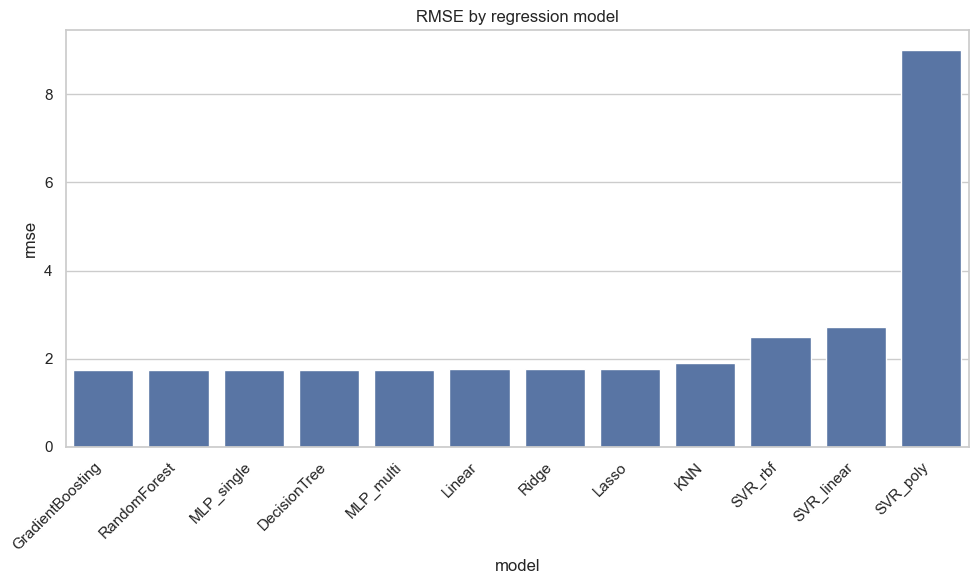

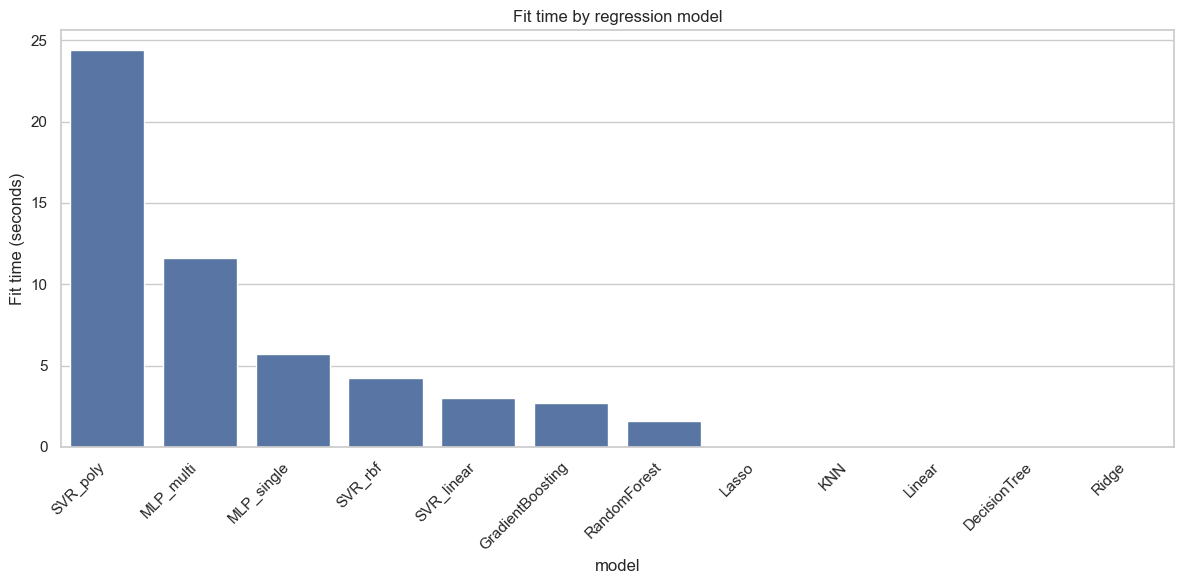

In [5]:
plot_regression_metrics(df_regression, 'rmse', 'RMSE by regression model', None)
plot_fit_times(df_regression, None, 'Fit time by regression model')


## Ridge and Lasso Alpha Analysis

This section analyses the regularisation strength `alpha` for Ridge and Lasso. In both models, alpha controls the penalty applied to model coefficients. Very small alpha values make the models behave similarly to ordinary linear regression, which can reduce bias but increase variance. Very large alpha values strongly shrink coefficients, which can reduce variance but increase bias and underfitting.

For Ridge Regression, increasing alpha usually stabilises coefficients in the presence of correlated predictors, especially after one-hot encoding. The best Ridge alpha is the value that minimises RMSE on the validation/test comparison while avoiding unnecessary complexity. For Lasso, increasing alpha can remove weak predictors by shrinking their coefficients to zero. This can be helpful in sparse feature spaces, but excessive shrinkage may discard useful categorical signals.

The plotted alpha curves should be read as an empirical bias-variance analysis. If RMSE decreases as alpha increases from a very small value, the unregularised model was likely too variable. If RMSE rises at high alpha values, the model has become too simple. The selected alpha therefore represents a compromise between flexibility and generalisation.


,model,alpha,fit_time,rmse,mae,r2
5,Lasso,0.001,0.151305,1.757200,1.359605,0.078639
6,Lasso,0.010,0.040673,1.762549,1.364117,0.073021
7,Lasso,0.100,0.014010,1.820698,1.402149,0.010848
8,Lasso,1.000,0.012025,1.830765,1.412113,-0.000121
9,Lasso,10.000,0.015584,1.830765,1.412113,-0.000121
0,Ridge,0.010,0.013608,1.756899,1.359155,0.078954
1,Ridge,0.100,0.013965,1.756901,1.359157,0.078953
2,Ridge,1.000,0.011436,1.756911,1.359175,0.078942
3,Ridge,10.000,0.010895,1.757029,1.359349,0.078818
4,Ridge,100.000,0.010147,1.758759,1.360961,0.077003


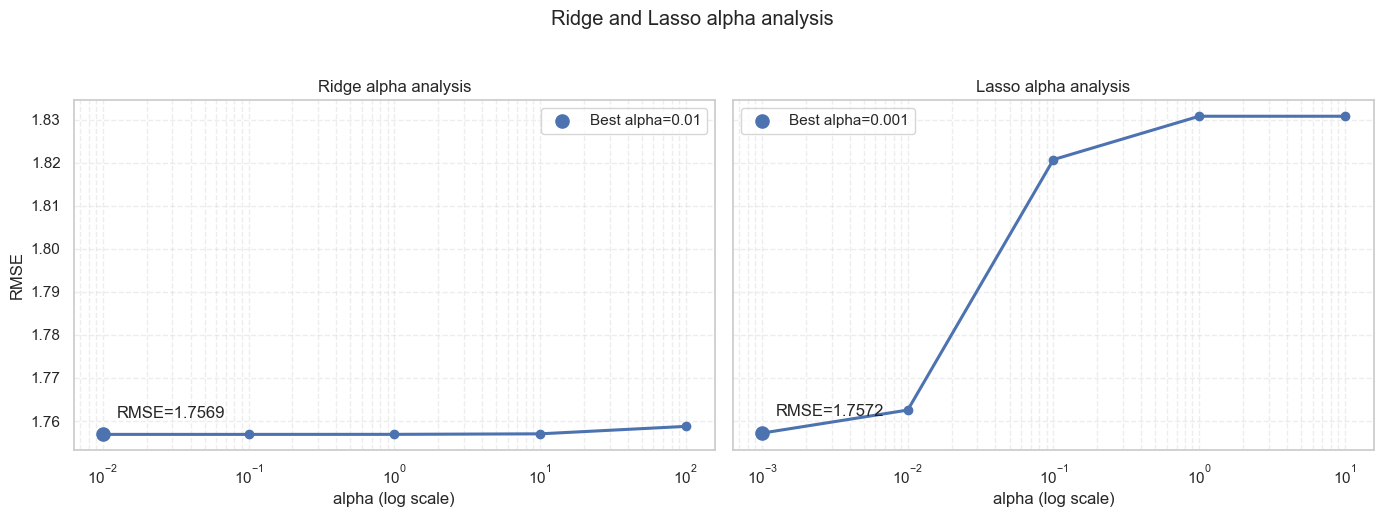

In [6]:
alpha_records = []
for model_name, alphas in {'Ridge': [0.01, 0.1, 1, 10, 100], 'Lasso': [0.001, 0.01, 0.1, 1, 10]}.items():
    for alpha in alphas:
        model = clone(models[model_name]).set_params(alpha=alpha)
        start = time.time()
        model.fit(X_train, y_train)
        fit_time = time.time() - start
        metrics = evaluate_model(f'{model_name}_alpha_{alpha}', model, X_test, y_test)
        alpha_records.append({'model': model_name, 'alpha': alpha, 'fit_time': fit_time, **metrics})

df_alpha = pd.DataFrame(alpha_records).sort_values(['model', 'alpha'])
display(df_alpha)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model_name in zip(axes, ['Ridge', 'Lasso']):
    subset = df_alpha[df_alpha['model'] == model_name].sort_values('alpha')
    best = subset.loc[subset['rmse'].idxmin()]
    ax.plot(subset['alpha'], subset['rmse'], marker='o', linewidth=2.2)
    ax.scatter(best['alpha'], best['rmse'], s=90, zorder=3, label=f"Best alpha={best['alpha']:g}")
    ax.annotate(
        f"RMSE={best['rmse']:.4f}",
        xy=(best['alpha'], best['rmse']),
        xytext=(10, 12),
        textcoords='offset points',
    )
    ax.set_xscale('log')
    ax.set_title(f'{model_name} alpha analysis')
    ax.set_xlabel('alpha (log scale)')
    ax.grid(True, which='both', linestyle='--', alpha=0.35)
    ax.legend()
axes[0].set_ylabel('RMSE')
fig.suptitle('Ridge and Lasso alpha analysis', y=1.03)
fig.tight_layout()
plt.savefig('../artifacts/rmse_by_model.png', dpi=150, bbox_inches='tight')
plt.savefig('../artifacts/fit_time_regression.png', dpi=150, bbox_inches='tight')
plt.savefig('../artifacts/alpha_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## K-NN Optimal K Analysis

K-NN regression predicts a score by averaging the target values of the nearest training observations. The number of neighbours, K, controls the smoothness of the model. A small K produces highly local predictions that can capture fine-grained patterns but may be noisy. A large K averages over more observations, reducing variance but potentially hiding meaningful differences between user-anime interactions.

The GridSearchCV results evaluate odd K values and weighting strategies. The optimal K is the configuration with the best cross-validated score, meaning it provides the best validation RMSE among the tested alternatives. In the context of this dataset, a moderate K is often expected because individual interactions are noisy but broad behavioural groups may still exist. If the selected K is very small, the data may contain strong local structure; if it is large, the model is relying on broad similarity patterns rather than individual neighbours.


In [7]:
knn_grid = GridSearchCV(
    clone(models['KNN']),
    {'n_neighbors': list(range(3, 32, 2)), 'weights': ['uniform', 'distance']},
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1,
)
knn_grid.fit(X_train, y_train)
print('Best KNN params:', knn_grid.best_params_)
display(pd.DataFrame(knn_grid.cv_results_)[['param_n_neighbors', 'param_weights', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(10))


Best KNN params: {'n_neighbors': 21, 'weights': 'uniform'}


,param_n_neighbors,param_weights,mean_test_score,rank_test_score
18,21,uniform,-2.990964,1
19,21,distance,-3.003088,2
12,15,uniform,-3.009318,3
10,13,uniform,-3.011847,4
24,27,uniform,-3.014920,5
22,25,uniform,-3.015864,6
16,19,uniform,-3.018154,7
14,17,uniform,-3.018789,8
28,31,uniform,-3.020016,9
13,15,distance,-3.021636,10


## Classification Models: Logistic Regression, Naive Bayes, SVM Kernels, K-NN, Gini Tree, Ensembles, and Neural Networks

The classification section transforms the project into a binary decision problem: predicting whether an interaction belongs to the high-score class. Logistic Regression is appropriate here because it estimates the probability of class membership through a linear decision boundary. It is not a regression model for continuous score prediction despite its name; the output is a class probability, not a numeric rating on the 0 to 10 scale.

Naive Bayes is also classification-only in this project. It estimates class probabilities under conditional independence assumptions between features. This assumption is often unrealistic for user behaviour data because variables such as completion, watched episodes, and rewatching can be related, but Naive Bayes remains useful as a fast probabilistic baseline. It is not suitable for predicting continuous `score` values without changing to a different probabilistic regression formulation, which is outside the assignment requirement.

SVC models test margin-based classification with linear and non-linear kernels. K-NN classification predicts the high-score class from neighbouring examples and therefore depends strongly on the selected K. Decision Trees with the Gini criterion provide interpretable rules, while Random Forest and Gradient Boosting reduce the instability of individual trees. Single-layer and multi-layer MLP classifiers test whether non-linear neural representations improve F1, precision, or recall compared with simpler classifiers.

Precision, recall, and F1 are central for this task. Precision measures how many predicted high-score cases are truly high-score, recall measures how many true high-score cases are detected, and F1 balances both. Accuracy can be misleading if the high-score and low-score classes are imbalanced.


In [8]:
df_class = df.copy()
df_class['high_score'] = (df_class['score'] >= 7).astype(int)
CLASS_TARGET = 'high_score'
X_class_df = df_class.drop(columns=['score', CLASS_TARGET]).copy()
y_class = df_class[CLASS_TARGET].copy()

Xc_train_df, Xc_test_df, yc_train, yc_test = train_test_split(
    X_class_df, y_class, test_size=0.2, random_state=RANDOM_STATE, stratify=y_class
)

preprocess_class = build_preprocess(df_class.drop(columns=['score']), CLASS_TARGET)
Xc_train = preprocess_class.fit_transform(Xc_train_df)
Xc_test = preprocess_class.transform(Xc_test_df)
class_feature_names = preprocess_class.get_feature_names_out()

clf_models = get_models('classification')

knn_clf_grid = GridSearchCV(
    clf_models['KNNClassifier'],
    {'n_neighbors': list(range(3, 32, 2)), 'weights': ['uniform', 'distance']},
    cv=5,
    scoring='f1',
    n_jobs=1,
)
knn_clf_grid.fit(Xc_train, yc_train)
clf_models['KNNClassifier'] = knn_clf_grid.best_estimator_
print('Best KNN classifier params:', knn_clf_grid.best_params_)

classification_results = []
while mlflow.active_run():
    mlflow.end_run()
with mlflow.start_run(nested=True, run_name='02_classification_models'):
    for name, model in clf_models.items():
        print(f'Training {name}...')
        start = time.time()
        model.fit(Xc_train, yc_train)
        fit_time = time.time() - start
        preds = model.predict(Xc_test)
        classification_results.append({
            'model': name,
            'fit_time': fit_time,
            **compute_classification_metrics(yc_test, preds),
        })

df_classification = pd.DataFrame(classification_results).sort_values('f1', ascending=False)
display(df_classification)


Best KNN classifier params: {'n_neighbors': 29, 'weights': 'uniform'}
Training LogisticRegression...
Training NaiveBayes...
Training SVC_linear...
Training SVC_rbf...
Training SVC_poly...
Training KNNClassifier...
Training DecisionTreeClassifier...
Training RandomForestClassifier...
Training GradientBoostingClassifier...
Training MLPClassifier_single...
Training MLPClassifier_multi...


,model,fit_time,accuracy,precision,recall,f1
9,MLPClassifier_single,6.300055,0.7567,0.753775,0.995118,0.857794
8,GradientBoostingClassifier,2.602099,0.7566,0.753750,0.994982,0.857727
5,KNNClassifier,0.066152,0.7565,0.753724,0.994847,0.857661
10,MLPClassifier_multi,13.857765,0.7565,0.753724,0.994847,0.857661
6,DecisionTreeClassifier,0.022282,0.7561,0.753363,0.994982,0.857477
1,NaiveBayes,0.020643,0.7539,0.754692,0.987117,0.855397
4,SVC_poly,148.691913,0.6530,0.770961,0.753187,0.761970
0,LogisticRegression,9.565626,0.6522,0.771460,0.750746,0.760962
2,SVC_linear,86.128356,0.6445,0.771660,0.735557,0.753176
3,SVC_rbf,128.868357,0.6428,0.771804,0.732031,0.751392


## Why Naive Bayes and Logistic Regression Are Classification-Only Here

The assignment requires both regression/prediction and classification algorithms. Naive Bayes and Logistic Regression satisfy the classification part because they estimate discrete class membership. In this notebook they are therefore applied to the derived `high_score` target, where the possible outcomes are `0` and `1`.

They are not applied to the continuous `score` regression task because their standard scikit-learn implementations do not optimise RMSE, MAE, or R2 for numeric targets. Logistic Regression models log-odds of class membership, and Naive Bayes models class-conditional probabilities. Applying them directly to a 0 to 10 score would incorrectly treat the score as a categorical label rather than an ordered numeric rating. For the score prediction task, the appropriate linear baselines are Linear Regression, Ridge, and Lasso.


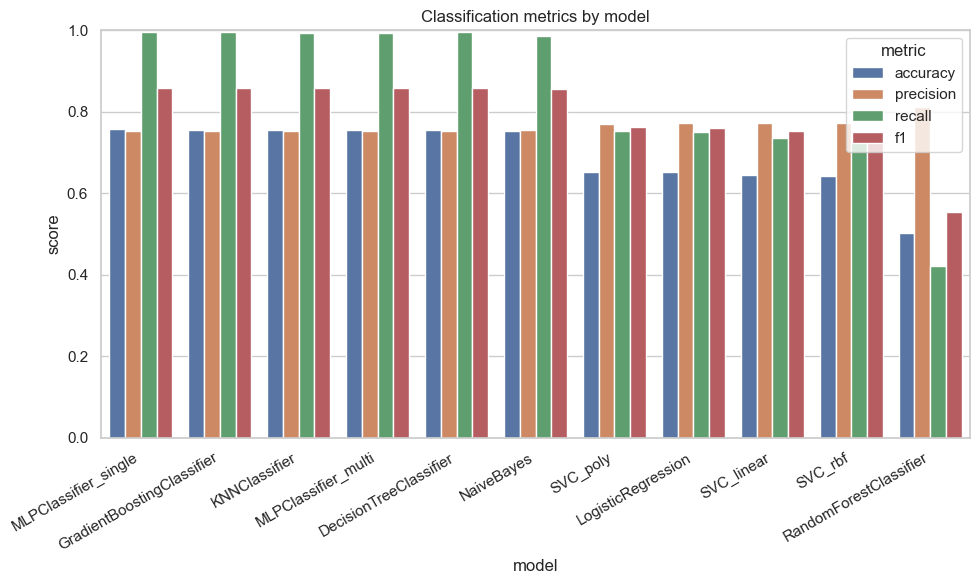

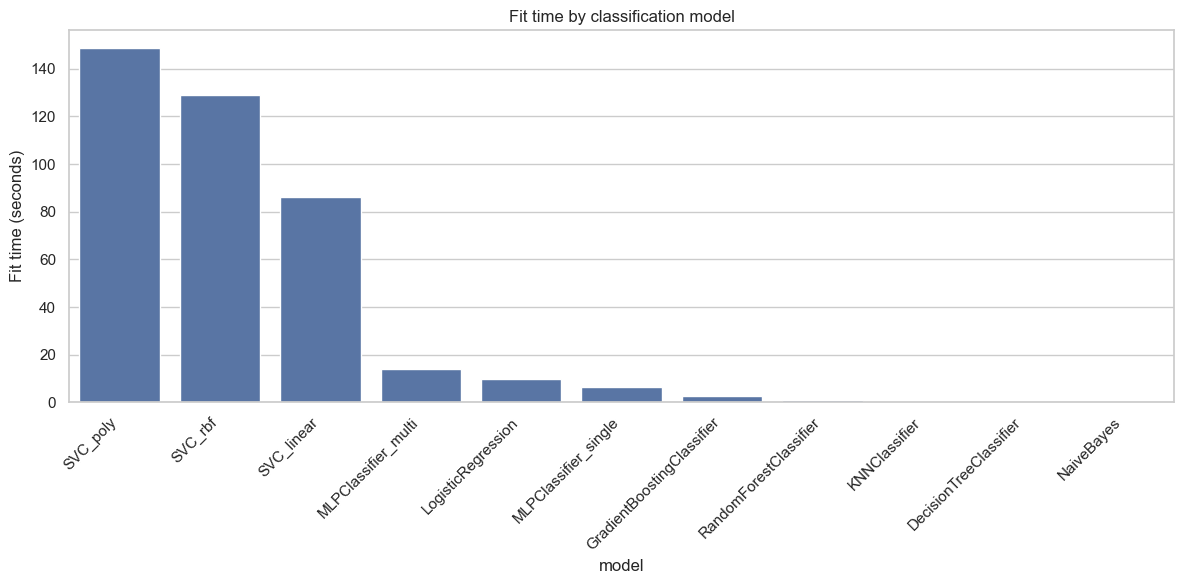

In [9]:
plot_classification_metrics(df_classification, None)
plot_fit_times(df_classification, None, 'Fit time by classification model')


## Decision Tree Gini Analysis and Random Forest Tree Image

The Decision Tree Classifier uses Gini impurity to decide how to split the data. Gini impurity measures class mixture at a node: a value close to 0 indicates that most observations belong to one class, while higher values indicate a more balanced mixture of high-score and non-high-score observations. The root Gini value describes the impurity before any split, so it reflects the initial class balance of the classification problem.

As the tree splits, useful features should reduce impurity by separating interactions into more homogeneous groups. The displayed depth and number of leaves indicate the complexity of the learned rule structure. A shallow tree is easier to interpret but may underfit, while a deeper tree can capture interactions but may overfit. Because the tree is limited with `max_depth`, the visualisation focuses on the most important early splits, which are the most discriminative decisions according to the Gini criterion.

The Random Forest tree image shows one representative tree from the ensemble. A single tree does not summarise the whole forest, but it provides a legible example of how the ensemble partitions the feature space. The forest as a model is usually more robust than the displayed tree because it averages many trees trained with randomness.


Decision Tree criterion: gini
Decision Tree root gini: 0.38730621875000004
Decision Tree depth: 5
Decision Tree leaves: 26


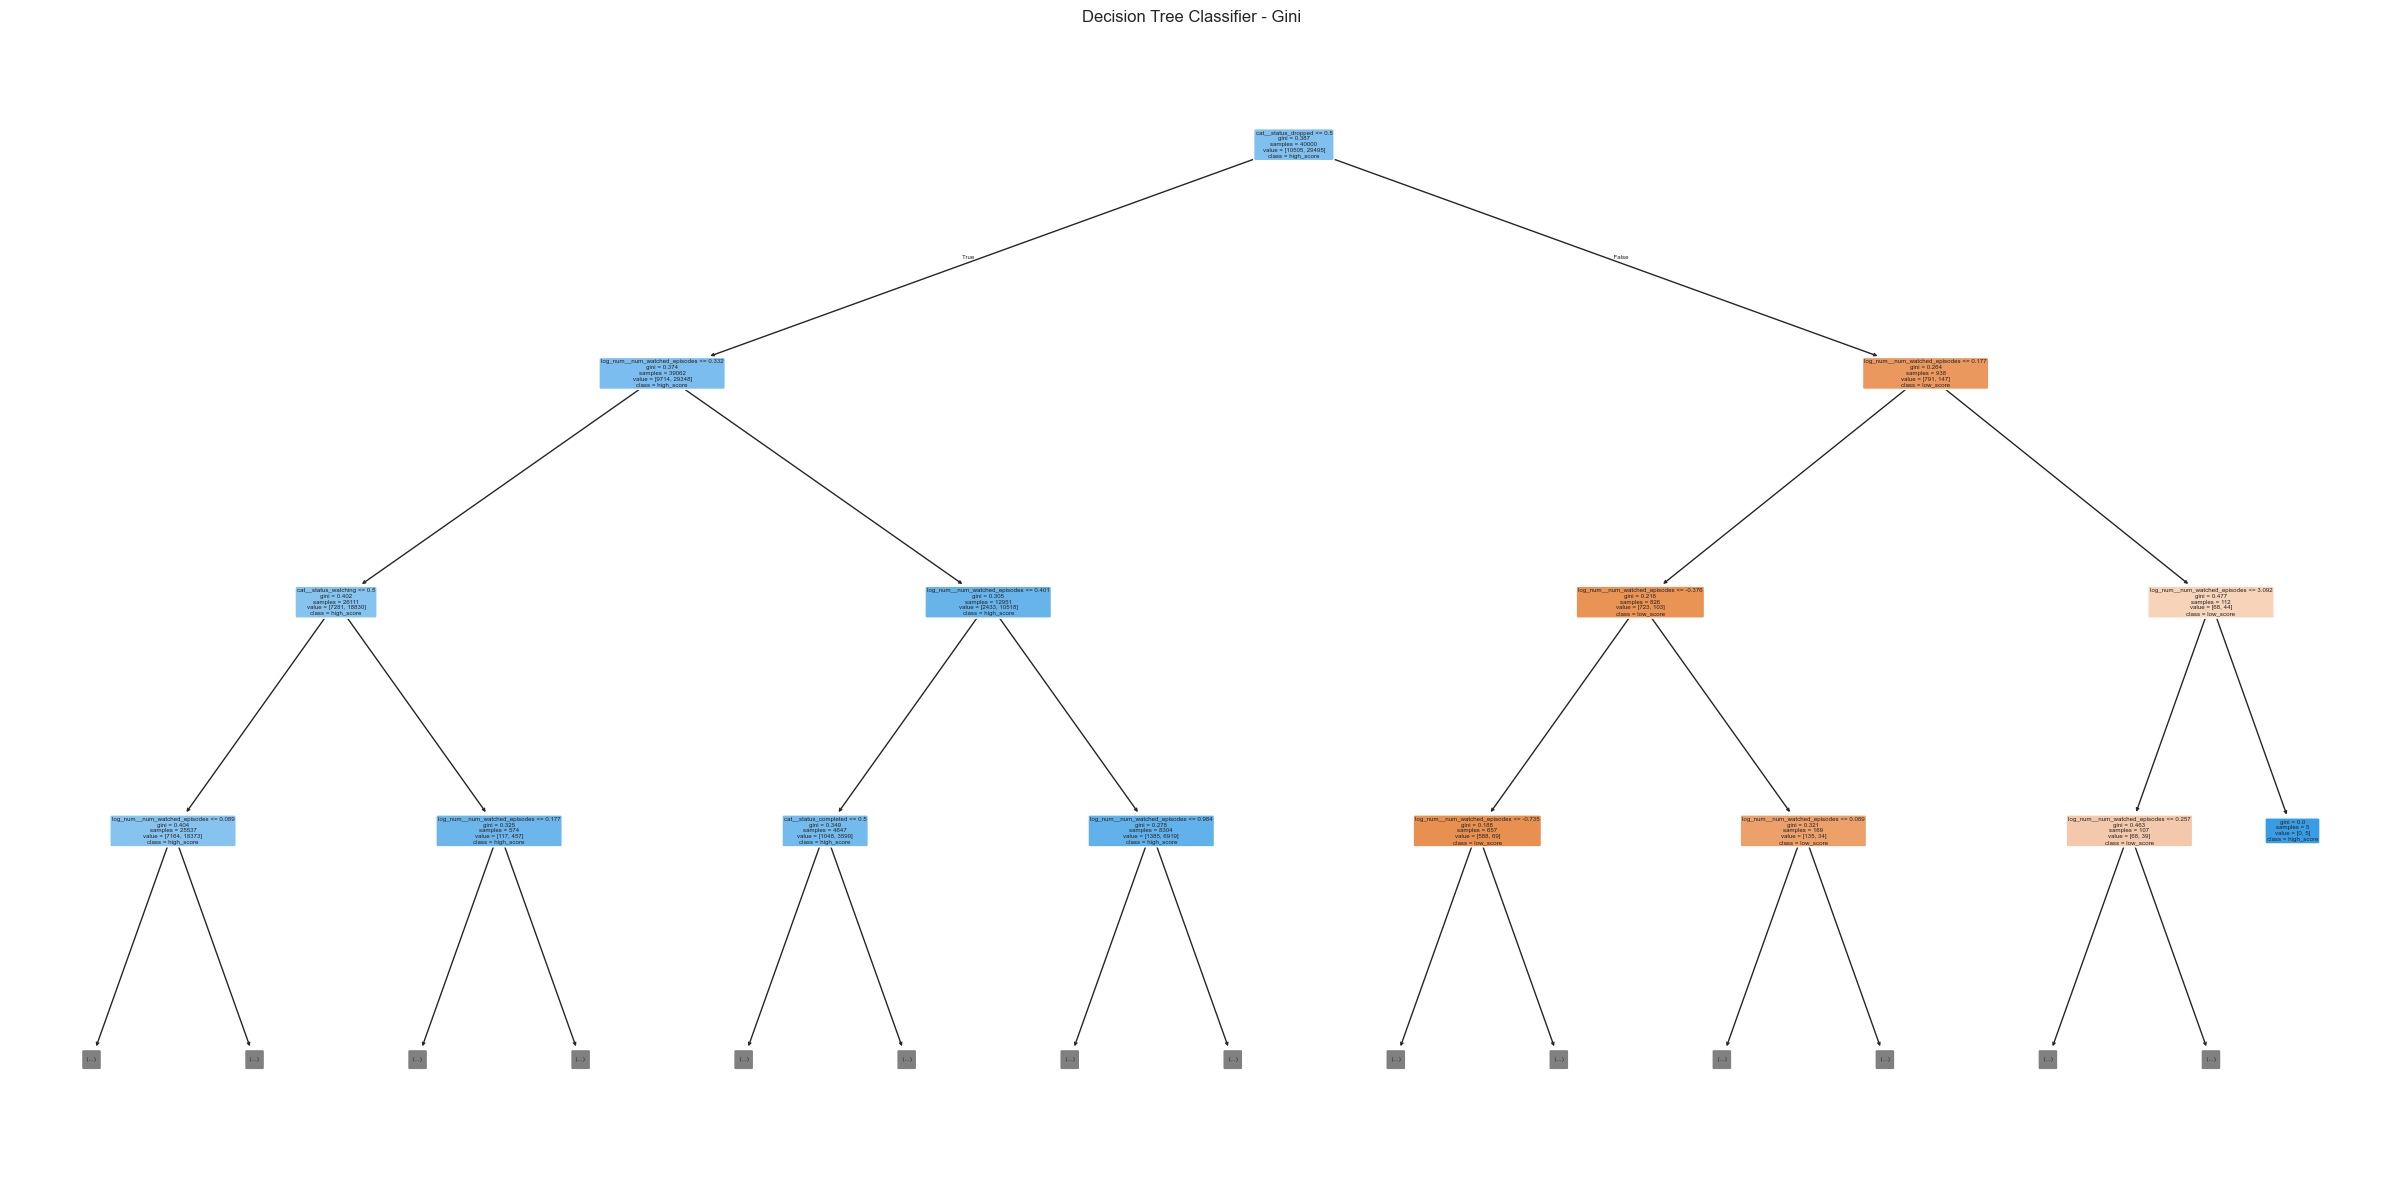

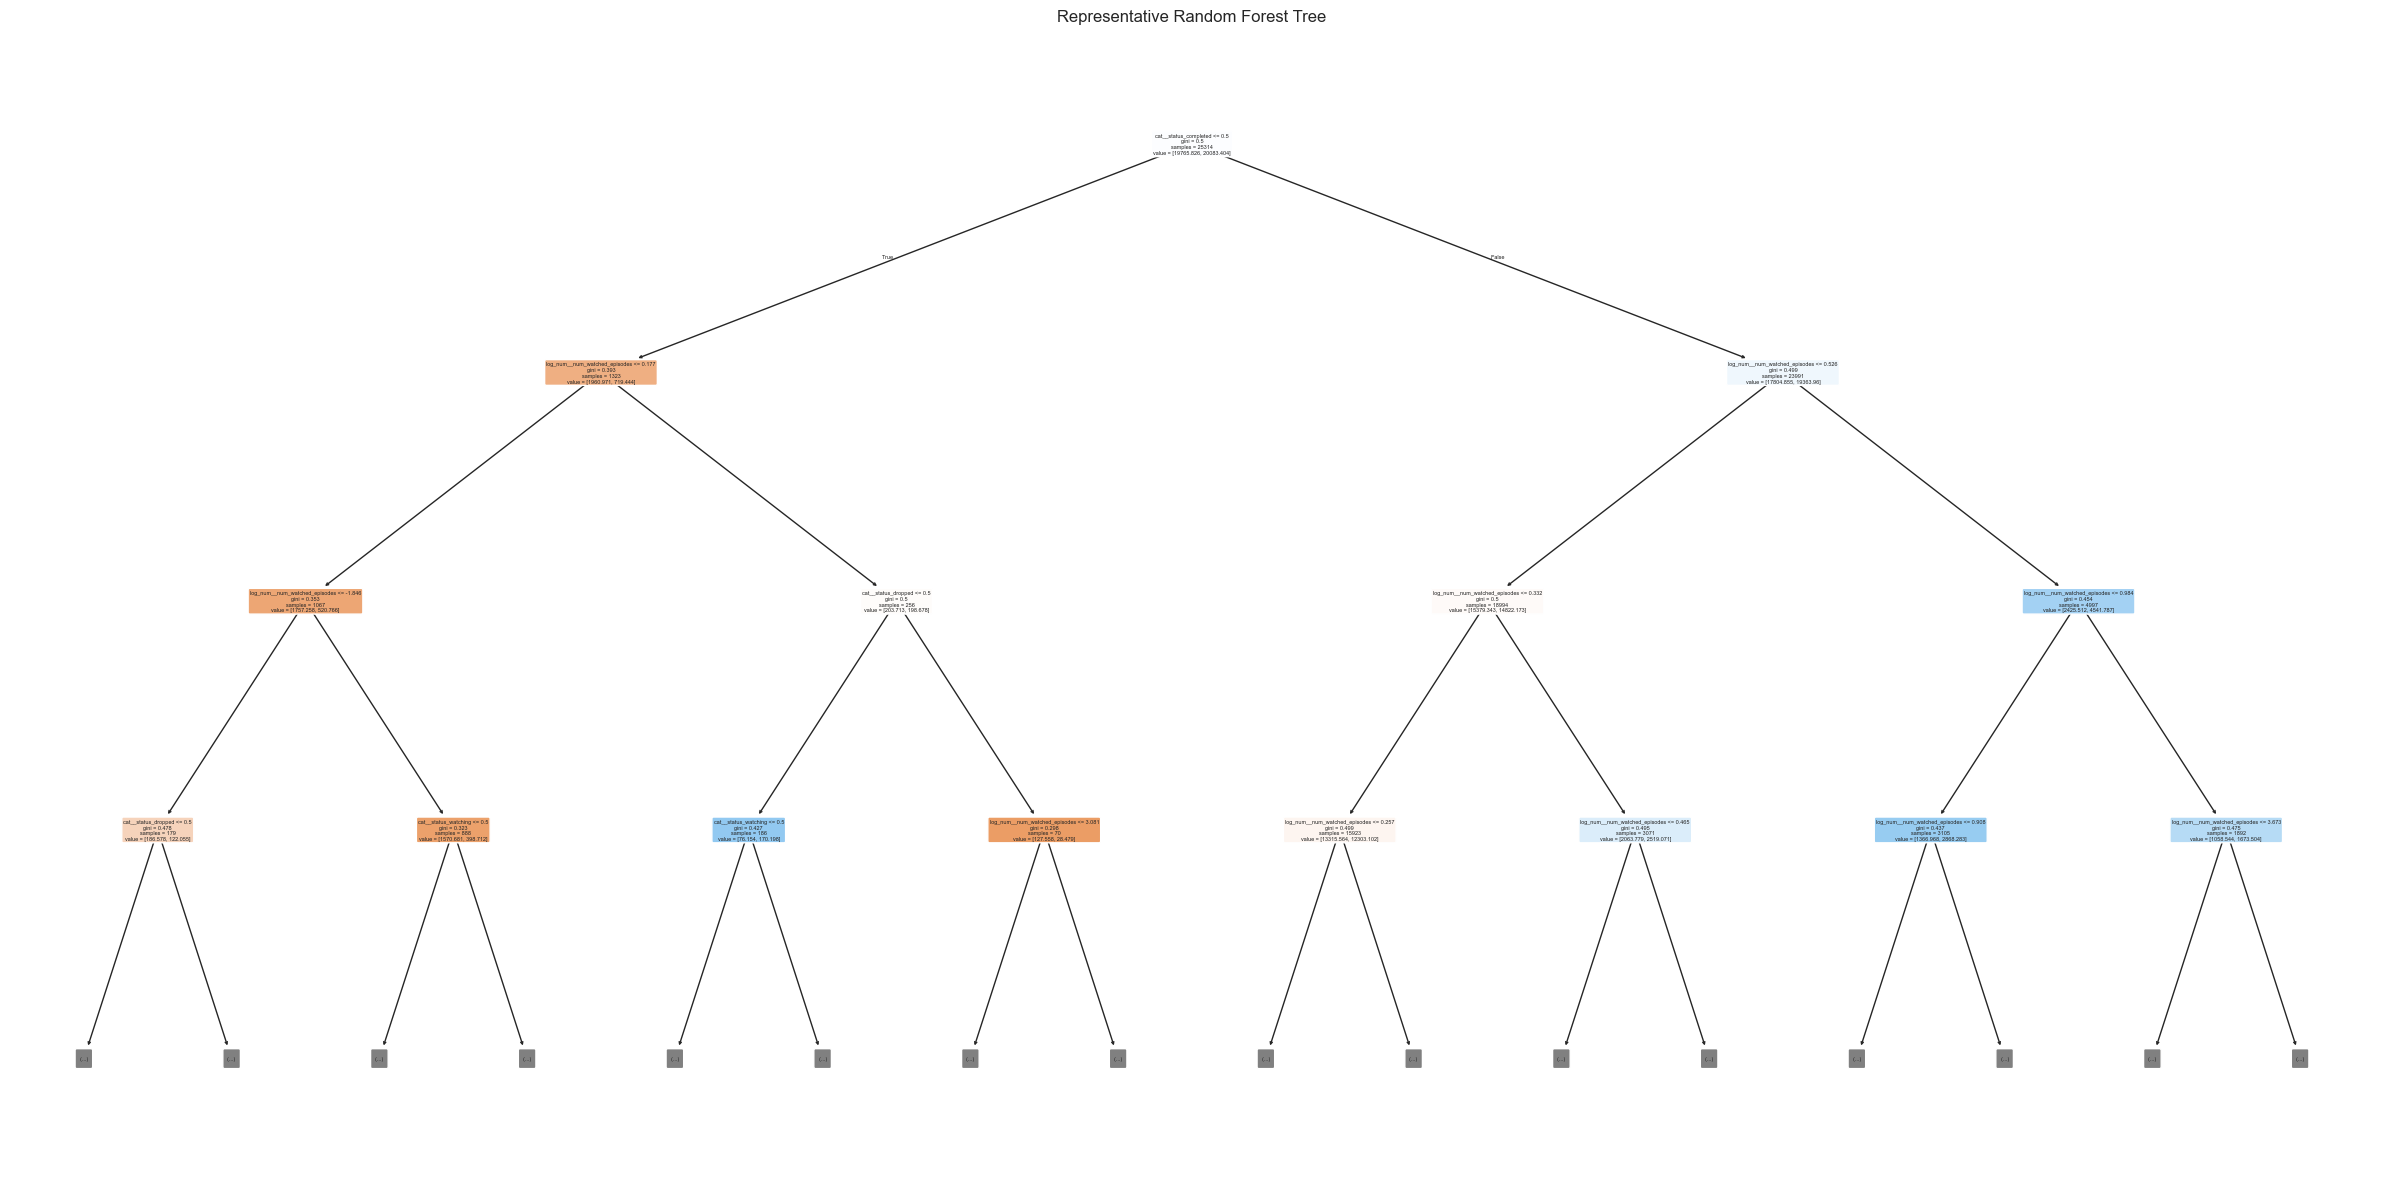

In [10]:
tree_model = clf_models['DecisionTreeClassifier']
rf_model = clf_models['RandomForestClassifier']

print('Decision Tree criterion:', tree_model.criterion)
print('Decision Tree root gini:', tree_model.tree_.impurity[0])
print('Decision Tree depth:', tree_model.get_depth())
print('Decision Tree leaves:', tree_model.get_n_leaves())

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=class_feature_names,
    class_names=['low_score', 'high_score'],
    filled=True,
    rounded=True,
    max_depth=3,
)
plt.title('Decision Tree Classifier - Gini')
plt.tight_layout()
plt.show()

plt.figure(figsize=(24, 12))
plot_tree(
    rf_model.estimators_[0],
    feature_names=class_feature_names,
    filled=True,
    rounded=True,
    max_depth=3,
)
plt.title('Representative Random Forest Tree')
plt.tight_layout()
plt.show()


## Critical Comparison

The regression table `df_regression` is sorted by RMSE, so the first row of that displayed table identifies the model with the best observed RMSE on the test set. This model is the strongest pure prediction candidate because RMSE penalises large rating errors more heavily than MAE, which is important on the bounded MyAnimeList score scale. However, the lowest-RMSE model should not be accepted automatically: its MAE and R2 must also be checked to confirm that the improvement is consistent and not driven only by a few unusually large errors.

The best RMSE/fit-time tradeoff is identified by comparing the RMSE ranking with the fit-time plot shown immediately after the regression results. If the model with the lowest RMSE also has moderate training time, it is the strongest practical choice for the final predictive application. If it is much slower than a second or third ranked model with very similar RMSE, the faster alternative may be preferable because it gives almost the same predictive quality with lower computational cost. This distinction is central to the assignment: model comparison must include both accuracy and execution time, not only the final error value.

Model family performance should also be interpreted in relation to the MyAnimeList data structure. If linear or regularised models appear near the top of the RMSE ranking, the encoded variables may contain mostly additive signals and the simpler models provide a strong tradeoff. If Random Forest, Gradient Boosting, SVR, or MLP models achieve the best RMSE, this suggests that non-linear interactions between status, watched episodes, rewatching, and categorical indicators are useful. K-NN can have low fitting time, but this does not necessarily mean it is the best operational model because prediction can be slower and its accuracy depends heavily on whether the scaled feature space defines meaningful neighbours.

For classification, the best model is the one with the strongest F1-score while maintaining an acceptable precision-recall balance. A high-precision model is conservative and avoids incorrectly labelling lower-score interactions as high-score, while a high-recall model captures more genuinely high-score cases. The single-layer versus multi-layer MLP comparison indicates whether additional neural network depth improves the decision boundary. If the multi-layer model does not clearly outperform the single-layer model, the added complexity and training time are not justified.

Overall, the final recommendation should explicitly name two models from the displayed results: the regression model with the lowest RMSE and the model with the best RMSE/time compromise. These may be the same model, but if they differ, the report should justify which one is more appropriate for dashboard integration. For a user-facing dashboard, a slightly less accurate but faster and more stable model can be more defensible than a slow model with only marginally better RMSE.
